# Decision Tree From Scratch

In [1]:
# importing all the necessary modules
import math
import numpy as np 
import pandas as pd
from sklearn.tree import DecisionTreeClassifier,plot_tree # for ploting decision tree 
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
# for calculating gini impurity
def gini(samples):
    s_sum=sum(samples)
    score=0
    probab=[]
    for sample in samples:
        prob=sample/s_sum
        probab.append(prob)
    for prob in probab:
        score+=prob*(1-prob)
    return score

In [3]:
gini([100,75,125])

0.6527777777777777

In [4]:
# for calculating Entropy
def entropy(samples):
    s_sum=sum(samples)
    score=0
    probab=[]
    for sample in samples:
        prob=sample/s_sum
        probab.append(prob)
    for prob in probab:
        if(prob>0):
            score+=prob*(math.log(prob))
    return -1*score

In [5]:
entropy([100,75,125])

1.0775563270668007

In [6]:
gini([100,0,0]), entropy([100,0,0])

(0.0, -0.0)

In [7]:
data=pd.read_csv("/kaggle/input/titanic/train.csv")

In [8]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [9]:
#using only 3 features i.e. Survived, Sex, Parch for simplicity
features=["Survived","Sex","Parch"]

In [10]:
new=data[features]

In [11]:
new

,Survived,Sex,Parch
0,0,male,0
1,1,female,0
2,1,female,0
3,1,female,0
4,0,male,0
...,...,...,...
886,0,male,0
887,1,female,0
888,0,female,2
889,1,male,0


In [12]:
# mapping Sex column from categorical to numerical 
sex_mapping={
    'female':0,
    'male':1
}
new["Sex"]=new["Sex"].map(sex_mapping)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [13]:
new

,Survived,Sex,Parch
0,0,1,0
1,1,0,0
2,1,0,0
3,1,0,0
4,0,1,0
...,...,...,...
886,0,1,0
887,1,0,0
888,0,0,2
889,1,1,0


In [14]:
new.Parch.value_counts()

0    678
1    118
2     80
3      5
5      5
4      4
6      1
Name: Parch, dtype: int64

In [15]:
new.Survived.value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [16]:
gini([549,342])

0.4730129578614427

In [17]:
new[new.Parch<=0.5].Survived.value_counts()

0    445
1    233
Name: Survived, dtype: int64

In [18]:
gini([445,233])

0.45111424369784464

In [19]:
new[new.Parch>0.5].Survived.value_counts()

1    109
0    104
Name: Survived, dtype: int64

In [20]:
gini([109,104])

0.4997244814741344

In [21]:
new[new.Parch<=1.5].Survived.value_counts()

0    498
1    298
Name: Survived, dtype: int64

In [22]:
gini([498,298])

0.4684351405267544

In [23]:
new[new.Parch>1.5].Survived.value_counts()

0    51
1    44
Name: Survived, dtype: int64

In [24]:
gini([51,44])

0.49728531855955677

In [25]:
new[new.Parch<=2.5].Survived.value_counts()

0    538
1    338
Name: Survived, dtype: int64

In [26]:
gini([538,338])

0.4739371572736181

In [27]:
new[new.Parch>2.5].Survived.value_counts()

0    11
1     4
Name: Survived, dtype: int64

In [28]:
gini([11,4])

0.3911111111111112

In [29]:
new[new.Parch<=3.5].Survived.value_counts()

0    540
1    341
Name: Survived, dtype: int64

In [30]:
gini([540,341])

0.4744891845892798

In [31]:
new[new.Parch>3.5].Survived.value_counts()

0    9
1    1
Name: Survived, dtype: int64

In [32]:
gini([9,1])

0.18

In [33]:
new[new.Parch<=4.5].Survived.value_counts()

0    544
1    341
Name: Survived, dtype: int64

In [34]:
gini([544,341])

0.47369274474129397

In [35]:
new[new.Parch>4.5].Survived.value_counts()

0    5
1    1
Name: Survived, dtype: int64

In [36]:
gini([5,1])

0.2777777777777778

In [37]:
new[new.Parch<=5.5].Survived.value_counts()

0    548
1    342
Name: Survived, dtype: int64

In [38]:
gini([548,342])

0.47321297815932334

In [39]:
new[new.Parch>5.5].Survived.value_counts()

0    1
Name: Survived, dtype: int64

In [40]:
gini([1,0])

0.0

In [41]:
new[new.Sex<=0.5].Survived.value_counts()

1    233
0     81
Name: Survived, dtype: int64

In [42]:
gini([233,81])

0.38283500344841576

In [43]:
new[new.Sex>0.5].Survived.value_counts()

0    468
1    109
Name: Survived, dtype: int64

In [44]:
gini([468,109])

0.3064437162277843

In [45]:
# for calculating weighted mean
p1=0.468
p2=0.497
s1=796
s2=95
(p1*s1+ p2*s2)/(s1+s2)


0.47109203142536477

In [46]:
new[(new.Sex<=0.5) & (new.Parch<=0.5)].Survived.value_counts()

1    153
0     41
Name: Survived, dtype: int64

In [47]:
gini([41,153])

0.33335104687001804

In [48]:
new[(new.Sex<=0.5) & (new.Parch>0.5)].Survived.value_counts()

1    80
0    40
Name: Survived, dtype: int64

In [49]:
gini([40,80])

0.4444444444444445

In [50]:
new[(new.Sex<=0.5) & (new.Parch<=1.5)].Survived.value_counts()

1    199
0     55
Name: Survived, dtype: int64

In [51]:
gini([55,199])

0.3392956785913571

In [52]:
new[(new.Sex<=0.5) & (new.Parch>1.5)].Survived.value_counts()

1    34
0    26
Name: Survived, dtype: int64

In [53]:
gini([26,34])

0.4911111111111111

In [54]:
new[(new.Sex<=0.5) & (new.Parch<=2.5)].Survived.value_counts()

1    229
0     74
Name: Survived, dtype: int64

In [55]:
gini([74,229])

0.3691577078499929

In [56]:
new[(new.Sex<=0.5) & (new.Parch>2.5)].Survived.value_counts()

0    7
1    4
Name: Survived, dtype: int64

In [57]:
gini([4,7])

0.4628099173553719

In [58]:
new[(new.Sex<=0.5) & (new.Parch<=3.5)].Survived.value_counts()

1    232
0     75
Name: Survived, dtype: int64

In [59]:
gini([75,232])

0.3692346868401787

In [60]:
new[(new.Sex<=0.5) & (new.Parch>3.5)].Survived.value_counts()

0    6
1    1
Name: Survived, dtype: int64

In [61]:
gini([6,1])

0.24489795918367352

In [62]:
new[(new.Sex<=0.5) & (new.Parch<=4.5)].Survived.value_counts()

1    232
0     77
Name: Survived, dtype: int64

In [63]:
gini([77,232])

0.37418962935034195

In [64]:
new[(new.Sex<=0.5) & (new.Parch>4.5)].Survived.value_counts()

0    4
1    1
Name: Survived, dtype: int64

In [65]:
gini([4,1])

0.32

In [66]:
new[(new.Sex<=0.5) & (new.Parch<=5.5)].Survived.value_counts()

1    233
0     80
Name: Survived, dtype: int64

In [67]:
gini([80,233])

0.380528534536435

In [68]:
new[(new.Sex<=0.5) & (new.Parch>5.5)].Survived.value_counts()

0    1
Name: Survived, dtype: int64

In [69]:
gini([1,0])

0.0

In [70]:
p1=0.381
p2=0
s1=313
s2=1
(p1*s1+ p2*s2)/(s1+s2)

0.37978662420382164

In [71]:
new[(new.Sex<=0.5) & (new.Parch<=3.5) &(new.Parch<=0.5)].Survived.value_counts()

1    153
0     41
Name: Survived, dtype: int64

In [72]:
gini([41,153])

0.33335104687001804

In [73]:
new[(new.Sex<=0.5) & (new.Parch<=3.5) &(new.Parch>0.5)].Survived.value_counts()

1    79
0    34
Name: Survived, dtype: int64

In [74]:
gini([34,79])

0.4207063983084032

In [75]:
new[(new.Sex<=0.5) & (new.Parch<=3.5) &(new.Parch<=1.5)].Survived.value_counts()

1    199
0     55
Name: Survived, dtype: int64

In [76]:
gini([55,199])

0.3392956785913571

In [77]:
new[(new.Sex<=0.5) & (new.Parch<=3.5) &(new.Parch>1.5)].Survived.value_counts()

1    33
0    20
Name: Survived, dtype: int64

In [78]:
gini([20,33])

0.46991812032751873

In [79]:
new[(new.Sex<=0.5) & (new.Parch<=3.5) &(new.Parch>2.5)].Survived.value_counts()

1    3
0    1
Name: Survived, dtype: int64

In [80]:
gini([1,3])

0.375

In [81]:
p1=0.369
p2=0.375
s1=303
s2=4
(p1*s1+ p2*s2)/(s1+s2)

0.36907817589576547

In [82]:
features

['Survived', 'Sex', 'Parch']

In [83]:
feat=["Sex","Parch"]

In [84]:
new[feat]

,Sex,Parch
0,1,0
1,0,0
2,0,0
3,0,0
4,1,0
...,...,...
886,1,0
887,0,0
888,0,2
889,1,0


In [85]:
model=DecisionTreeClassifier()
model.fit(new[feat],new.Survived)

DecisionTreeClassifier()

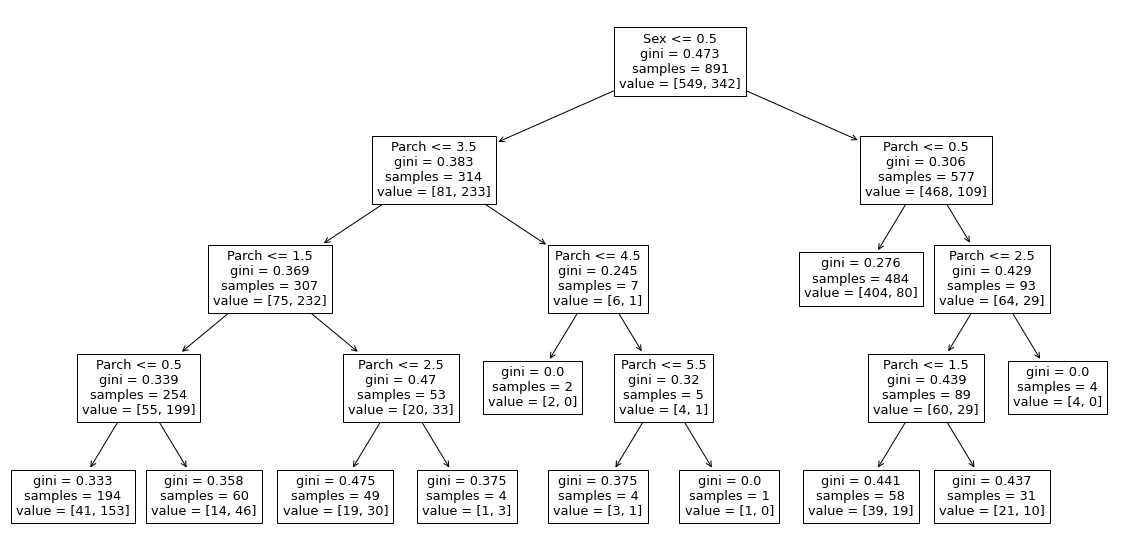

In [86]:
plt.figure(figsize=(20,10))
plot_tree(model,feature_names=feat)
plt.show()

# This is the final Decision Tree.

****If you like my work, Please UPVOTE! I will come with more algorithms from scratch.****